# **Mini-projet Rappels de Statistique Mathématique**
Aicha DIAKITE - Seynabou NIANG - Louise RIGAL

## **Objectif** :

On cherche à modéliser le comportement d’achat de clients dans une relation non contractuelle (“buy till you die”), puis à estimer des grandeurs d’intérêt liées à la fréquence d’achat et à la probabilité d’être encore actif, afin de construire une estimation de la VVC (Valeur Vie Client / Customer Lifetime Value).

*Notre cadre est celui du TP2 (Buy Til You Die ! VVC et modèle Pareto/NBD en marketing).*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##**Plan**

1. **Rappels sur les lois de Poisson, Gamma, mélange Gamma–Poisson** ⇒ Binomiale négative. (ils nous servirons pour les questions théoriques sur les modèles)


*Pour la suite, nous suivons en général le déroulé du TP2 Buy Til You Die*


2. **Calculs préliminaires**

    2.1 - **La loi binomiale négative**

    2.2 - **La loi de Pareto**

    2.3 - **Étude théorique du modèle NBD**

    2.4 - **Notes sur le modèle Pareto/NBD**

3. **Etude empirique**

    3.2 - **Données réelles (CDNOW)** : utilisation de la librairie Python lifetimes

## 1. Rappels : loi de Poisson, loi Gamma et mélange Gamma–Poisson

On rappelle que si $X \mid \Lambda = \lambda \sim \mathcal{P}(\lambda)$, alors :

$$
\mathbb{P}(X = k \mid \lambda) = e^{-\lambda}\frac{\lambda^k}{k!},
\quad k \in \mathbb{N}.
$$

Dans le modèle *Buy Till You Die* (BTYD), l’hétérogénéité entre individus est modélisée
par une variable aléatoire $\Lambda$ suivant une loi Gamma.

Pour $r>0$ et $\alpha>0$, si $\Lambda \sim \Gamma(r,\alpha)$ (paramétrée par un paramètre
de forme *shape* $r$ et un paramètre de taux *rate* $\alpha$), alors :

$$
\mathbb{E}[\Lambda] = \frac{r}{\alpha},
\qquad
\mathrm{Var}(\Lambda) = \frac{r}{\alpha^2}.
$$

### Mélange Gamma–Poisson

Si $\Lambda \sim \Gamma(r,\alpha)$ et $X \mid \Lambda \sim \mathcal{P}(\Lambda)$,
alors la loi marginale de $X$ est une **loi binomiale négative**.

Ce résultat fondamental permet d’expliquer la **sur-dispersion**
($\mathrm{Var}(X) > \mathbb{E}[X]$) observée dans les données de comptage,
et justifie l’utilisation de la binomiale négative dans le cadre du modèle BTYD.


###Vérification Gamma–Poisson

In [ ]:
!pip -q install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres Gamma (shape r, rate alpha)
r, alpha = 2.0, 1.5
N = 200000

Lambda = np.random.gamma(shape=r, scale=1/alpha, size=N)   # scale = 1/rate
X = np.random.poisson(lam=Lambda)

print("E[X] empirique :", X.mean(), " / Var[X] empirique :", X.var())

E[X] empirique : 1.338345  / Var[X] empirique : 2.2266376609750003


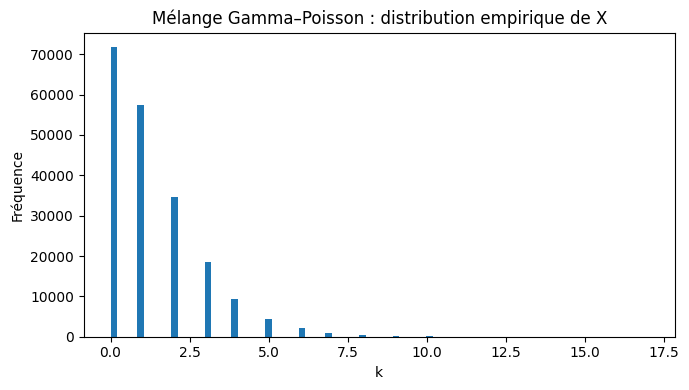

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(X, bins=80)
plt.title("Mélange Gamma–Poisson : distribution empirique de X")
plt.xlabel("k")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

###Illustration empirique du mélange Gamma–Poisson

Nous avons simulé une variable aléatoire $X$ selon le schéma suivant :

$$
\Lambda \sim \Gamma(r,\alpha), \qquad
X \mid \Lambda \sim \mathrm{P}(\Lambda).
$$

La distribution empirique de $X$ est représentée sur l’histogramme ci-dessus.
Les moments empiriques sont donnés par :
$$
\mathbb{E}[X]_{\text{emp}} \approx 1.34,
\qquad
\mathrm{Var}(X)_{\text{emp}} \approx 2.23.
$$

On observe clairement que :
$$
\mathrm{Var}(X)_{\text{emp}} > \mathbb{E}[X]_{\text{emp}}.
$$

Or, pour une loi de Poisson de paramètre $\lambda$, on a nécessairement :
$$
\mathbb{E}[X] = \mathrm{Var}(X) = \lambda.
$$

La sur-dispersion observée exclut donc un modèle de Poisson simple.
En revanche, elle est parfaitement cohérente avec le résultat théorique
du mélange Gamma–Poisson, selon lequel la loi marginale de $X$ est une
loi binomiale négative, dont la variance est strictement supérieure à
l’espérance.

Cette simulation illustre ainsi le rôle fondamental de l’hétérogénéité
entre individus dans la modélisation des données de comptage, et motive
l’utilisation de la loi binomiale négative dans le cadre du modèle BTYD.


# **2 Calculs préliminaires**


## **2.1 — Loi binomiale négative**


La loi binomiale négative de paramètres $r>0$ et $p \in (0,1)$
est une loi discrète définie sur $\mathbb{N}$ par :

$$
\mathbb{P}(X = k)
= \frac{\Gamma(r+k)}{\Gamma(r)\,k!}\, p^r (1-p)^k,
\qquad k \in \mathbb{N}.
$$

On note $q = 1-p$ la probabilité d’échec.

Lorsque $r$ est un entier naturel, cette loi admet l’interprétation probabiliste
suivante : la variable aléatoire $X$ représente le nombre d’échecs observés
avant l’obtention du $r$-ième succès dans une suite d’expériences de Bernoulli
indépendantes de probabilité de succès $p$.

Dans la suite de ce projet, cette interprétation sera remplacée par une
interprétation équivalente, plus adaptée aux données de comptage, via un
mélange Gamma–Poisson.

###**2.1.1 - Fonction génératrice des moments**

On suppose dans un premier temps que $r \in \mathbb{N}^*$.
La fonction génératrice des moments (FGM) de $X$ est définie par :

$$
G_X(t) = \mathbb{E}[t^X],
\qquad t \in \mathbb{R} \text{ tel que } |qt| < 1.
$$

Un calcul classique permet de montrer que la FGM de la loi binomiale négative
est donnée par :

$$
G_X(t) = \left( \frac{p}{1 - q t} \right)^r.
$$


---
**Calcul de l’espérance de la loi binomiale négative**

Par définition, l’espérance de $X$ est donnée par :
$$
\mathbb{E}[X] = G_X'(1).
$$

En dérivant la fonction génératrice, on obtient :
$$
G_X'(t)
= r \left( \frac{p}{1 - q t} \right)^r \frac{q}{1 - q t}.
$$

En évaluant cette dérivée en $t = 1$, il vient :
$$
\mathbb{E}[X]
= r \frac{q}{p}.
$$

On obtient donc :
$$
\boxed{\mathbb{E}[X] = \frac{r(1-p)}{p}.}
$$


---

**Calcul de la variance**

De manière analogue, on peut calculer la variance à partir de la dérivée seconde
de la fonction génératrice. On obtient alors :

$$
\mathrm{Var}(X)
= \frac{r q}{p^2}.
$$

On remarque immédiatement que :
$$
\mathrm{Var}(X) > \mathbb{E}[X],
$$

ce qui met en évidence la **sur-dispersion** caractéristique de la loi binomiale
négative.

Cette propriété distingue fondamentalement la loi binomiale négative de la loi
de Poisson, pour laquelle l’espérance et la variance sont égales.


###**2.1.2 - Estimateurs des moments**

Soit $(X_1,\dots,X_n)$ un échantillon i.i.d. suivant une loi binomiale négative
de paramètres $(r,p)$.

On note :
- $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$ la moyenne empirique,
- $S^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2$ la variance empirique.

La méthode des moments consiste à identifier les moments empiriques
aux moments théoriques, ce qui conduit aux estimateurs suivants :

$$
\hat{p}_{MM} = \frac{\bar{X}}{S^2},
\qquad
\hat{r}_{MM} = \frac{\bar{X}^2}{S^2 - \bar{X}},
$$

sous la condition naturelle $S^2 > \bar{X}$.

Cette condition traduit empiriquement la sur-dispersion des données et sera
vérifiée dans les applications numériques présentées par la suite.


###**2.1.3 - Estimateurs du maximum de vraisemblance**



Soit $(X_1,\dots,X_n)$ un échantillon i.i.d. suivant une loi binomiale négative
de paramètres $(r,p)$, avec $r>0$ et $p \in (0,1)$ (et $q = 1-p$).
La fonction de masse est :

$$
\mathbb{P}(X_i = x_i)
= \frac{\Gamma(r+x_i)}{\Gamma(r)\,x_i!}\, p^r q^{x_i},
\qquad x_i \in \mathbb{N}.
$$

La vraisemblance de $(r,p)$ au vu de l’échantillon s’écrit :

$$
L(r,p)
= \prod_{i=1}^n
\frac{\Gamma(r+x_i)}{\Gamma(r)\,x_i!}\, p^r q^{x_i}.
$$

En passant au logarithme, on obtient la log-vraisemblance :

$$
\ell(r,p)
= \sum_{i=1}^n \ln\Gamma(r+x_i)
- n\ln\Gamma(r)
- \sum_{i=1}^n \ln(x_i!)
+ nr\ln p
+ \left(\sum_{i=1}^n x_i\right)\ln q.
$$

Les estimateurs du maximum de vraisemblance $(\hat r,\hat p)$ sont définis
comme solutions du système des équations du score :

$$
\frac{\partial \ell}{\partial p}(r,p)=0,
\qquad
\frac{\partial \ell}{\partial r}(r,p)=0.
$$

---
**Équation du score en $p$**

On calcule :

$$
\frac{\partial \ell}{\partial p}(r,p)
= \frac{nr}{p} - \frac{\sum_{i=1}^n x_i}{1-p}.
$$

En imposant $\frac{\partial \ell}{\partial p}=0$, on obtient :

$$
\frac{nr}{p} = \frac{\sum_{i=1}^n x_i}{1-p}
\quad\Longleftrightarrow\quad
p = \frac{nr}{nr + \sum_{i=1}^n x_i}.
$$

En notant $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$, cela s’écrit aussi :

$$
\boxed{\ \hat p(r) = \frac{r}{r+\bar{X}} \ }.
$$

Ainsi, conditionnellement à $r$, l’estimateur MV de $p$ admet une expression
fermée.

---
**Équation du score en $r$**

On utilise la fonction digamma $\psi(\cdot)$ définie par :

$$
\psi(u) = \frac{d}{du}\ln\Gamma(u).
$$

On calcule :

$$
\frac{\partial \ell}{\partial r}(r,p)
= \sum_{i=1}^n \psi(r+x_i) - n\psi(r) + n\ln p.
$$

La condition du maximum de vraisemblance donne donc l’équation :

$$
\sum_{i=1}^n \psi(r+x_i) - n\psi(r) + n\ln p = 0.
$$

En remplaçant $p$ par son expression $\hat p(r)=\frac{r}{r+\bar{X}}$, on obtient
une équation scalaire en $r$ :

$$
\boxed{
\sum_{i=1}^n \psi(r+x_i) - n\psi(r)
+ n\ln\!\left(\frac{r}{r+\bar{X}}\right)
= 0.
}
$$

Cette équation n’admet pas, en général, de solution explicite : la valeur
$\hat r$ est donc obtenue par **résolution numérique** (méthodes de Newton,
quasi-Newton, etc.). On en déduit ensuite :

$$
\boxed{\ \hat p = \frac{\hat r}{\hat r + \bar{X}} \ }.
$$

Ces estimateurs MV seront comparés aux estimateurs des moments dans la suite
sur données simulées puis sur données réelles.


###**2.1.4 - Mélange Gamma–Poisson et interprétation statistique**

Soit $X$ une variable aléatoire telle que, conditionnellement à $\Lambda = \lambda$ :

$$
X \mid \Lambda = \lambda \sim \mathrm{P}(\lambda),
$$

où le paramètre aléatoire $\Lambda$ suit une loi Gamma de paramètres $(r,\theta)$,
de densité :

$$
f_\Lambda(\lambda)
= \frac{\lambda^{r-1}}{\Gamma(r)\,\theta^r}
e^{-\lambda/\theta} \mathbf{1}_{\mathbb{R}_+}(\lambda).
$$

Alors, la loi marginale de $X$ est une loi binomiale négative de paramètres $(r,p)$,
avec :
$$
p = \frac{1}{1+\theta}.
$$

Ce résultat, connu sous le nom de **mélange Gamma–Poisson**, montre que la loi
binomiale négative apparaît naturellement comme un modèle de données de
comptage hétérogènes.

Il constitue le socle probabiliste du modèle Pareto/NBD utilisé par la suite
pour la modélisation du comportement d’achat des clients dans le cadre de la
valeur vie client.


## Passage du cadre théorique au cadre applicatif : modèle BTYD et données réelles

Les sections précédentes ont permis d’étudier en détail la loi binomiale négative
et de montrer qu’elle apparaît naturellement comme la loi marginale d’un
mélange Gamma–Poisson. Ce résultat met en évidence le rôle central de
l’hétérogénéité entre individus dans la modélisation des données de comptage.

Dans le contexte de l’analyse du comportement d’achat des clients, cette
hétérogénéité est particulièrement marquée : certains clients achètent très
fréquemment, tandis que d’autres effectuent peu d’achats, voire cessent toute
activité après un temps plus ou moins long. Le cadre probabiliste *Buy Till You Die*
(BTYD) a précisément été introduit pour modéliser ce type de comportement.


### Le cadre Buy Till You Die (BTYD)

Les modèles BTYD reposent sur l’hypothèse que, tant qu’un client est actif,
ses achats suivent un processus ponctuel aléatoire, et que le client cesse
définitivement d’acheter à un instant aléatoire non observé.

Plus précisément, dans le modèle Pareto/NBD :

- conditionnellement à un taux individuel $\lambda_i$, les achats du client $i$
  suivent un processus de Poisson homogène ;

- la durée de vie du client est modélisée par une variable aléatoire continue,
  indépendante du processus d’achat conditionnel ;

- l’hétérogénéité entre clients est introduite en supposant que les paramètres
  individuels suivent des lois Gamma.

Ce cadre permet de relier les observations empiriques à une vraisemblance
paramétrée par un nombre fini de paramètres globaux, tout en conservant une
interprétation probabiliste claire.


### Lien avec la loi binomiale négative

Dans le modèle BTYD, la fréquence d’achat observée sur une période donnée
résulte d’un mélange de processus de Poisson dont les taux varient d’un client
à l’autre. Comme montré en section 2.1, un tel mélange Gamma–Poisson conduit
naturellement à une loi binomiale négative pour la distribution marginale du
nombre d’achats.

Ainsi, l’étude détaillée de la loi binomiale négative constitue un préalable
théorique essentiel à la compréhension et à l’estimation des modèles BTYD :
elle permet notamment de justifier la sur-dispersion observée dans les données
réelles et d’introduire les outils d’estimation (méthode des moments, maximum
de vraisemblance) utilisés par la suite.


Nous ferons le lien entre notre cadre théorique et applicatif dans les sections suivantes, en analysant la strcuture des données et les paramètres de la loi binomiale négative.

##

## **2.2 — Loi de Pareto**

La densité d'une loi de Pareto  $\mathcal{P}(\alpha, c)$ est donnée par

$$
f(x) =\dfrac{\alpha c^\alpha}{x^{\alpha+1}} \, \mathbf{1}_{[c,+\infty[}(x)
$$
(9) dans l'énoncé

#### **Question 5 - Fonction de répartition**

Soit une variable aléatoire $X$ suivant une loi de Pareto de paramètres
$\alpha > 0$ et $c > 0$, notée $X \sim \mathcal{P}(\alpha, c)$

Puisque la densité est nulle sur ${]-\infty,c[}$, on distingue deux cas :

$\forall x < c, $
$$F_X(x) = 0$$

$\forall x > c, $

$$F_X(x) = \mathbb{P}(X ≤ x)$$
ie, $$F_X(x) = \int_{c}^{x} f(t)\,dt$$
ie, $$F_X(x) = \int_{c}^{x} \dfrac{\alpha c^\alpha}{t^{\alpha+1}}\,dt$$
ie, $$F_X(x) =  \left[ \dfrac{-\alpha c^\alpha}{\alpha t^{\alpha}} \right]_c^x$$
ie, $$F_X(x) =  1- \left( \dfrac{c}{x} \right)^\alpha  $$

On obtient finalement :
$$
F_X(x) =
\begin{cases}
0 & \text{si } x < c \\
1 - \left( \dfrac{c}{x} \right)^\alpha & \text{si } x \geq c
\end{cases}
$$


#### **Question 6 - Espérance et Variance**

Par définition, X admet une espérance si et seulement si
$$\int_{-\infty}^{+\infty} tf(t)\,dt$$ converge absolument.

Or, $$\int_{-\infty}^{+\infty} tf(t)\,dt = \int_{c}^{+\infty} t\dfrac{\alpha c^\alpha}{t^{\alpha+1}}\,dt$$

$$=\int_{c}^{+\infty} \dfrac{\alpha c^\alpha}{t^{\alpha}}\,dt$$

Par comparaison avec une intégrale de Riemann, X admet une espérance si et seulement si $\alpha$ > 1

On suppose donc $\alpha$ > 1,

$$
\mathbb{E}[X] = \int_{c}^{+\infty} \dfrac{\alpha c^\alpha}{t^{\alpha}}\,dt
$$

ie,
$$
\mathbb{E}[X] =  \alpha c^\alpha \left[ \dfrac{-1}{(\alpha -1) t^{\alpha-1}} \right]_c^{+\infty}
$$

ie,
$$
\mathbb{E}[X] = \dfrac{\alpha c}{(\alpha -1)}
$$ car $\lim_{x \to +\infty} x^{-\alpha}$ = 0


Par définition, X admet une variance si et seulement si
$$\int_{-\infty}^{+\infty} t^2f(t)\,dt$$ converge absolument.

Or,

$$\int_{-\infty}^{+\infty} t^2f(t)\,dt = \int_{c}^{+\infty} t^2\dfrac{\alpha c^\alpha}{t^{\alpha+1}}\,dt$$

$$=\int_{c}^{+\infty} \dfrac{\alpha c^\alpha}{t^{\alpha - 1}}\,dt$$

Par comparaison avec une intégrale de Riemann, X admet une variance si et seulement si $\alpha$ > 2

On suppose donc $\alpha$ > 2,

$$
\mathbb{E}[X^2] = \int_{c}^{+\infty} \dfrac{\alpha c^\alpha}{t^{\alpha - 1}}\,dt
$$

ie,
$$
\mathbb{E}[X^2] =  \alpha c^\alpha \left[ \dfrac{-1}{(\alpha -2) t^{\alpha-2}} \right]_c^{+\infty}
$$

ie,
$$
\mathbb{E}[X^2] = \dfrac{\alpha c^2}{(\alpha -2)}
$$ car $\lim_{x \to +\infty} x^{-(\alpha-2)}$ = 0


D'après la formule de König-Huygens,
$$
\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2
$$

Donc,

$$\mathrm{Var}(X) =  \dfrac{\alpha c^2}{\alpha -2} - \dfrac{\alpha^2 c^2}{(\alpha -1)^2} $$

Finalement,
$$\mathrm{Var}(X) =
\dfrac{\alpha c^2}{(\alpha - 1)^2(\alpha - 2)}$$

#### **Question 7 - Fonction de répartition du maximum des $X_i$**

Soit $X = (X_1, \dots, X_n)$ un n-échantillon de Pareto dont on note $F$ la fonction de répartition.

Soit
$$
M_n = \max(X_1, \dots, X_n)
$$ de fonction de répartition $F_n$.



La fonction de répartition de $M_n$, notée , est donnée par :
$$
F_n(x)= \mathbb{P}(M_n \le x)
= \mathbb{P}(X_1 \le x, \dots, X_n \le x)
= \prod_{i=1}^n \mathbb{P}(X_i \le x)$$
Donc,
$$
\forall x \geq c, F_n(x)= \left( F(x) \right)^n
$$

#### **Question 8 - Estimateur par la méthode du maximum de vraisemblance de $c$**

Soit $x=(x_1, \dots, x_n)$ un n-échantillon observé de $X_1, ..., X_n$ de loi de Pareto. Sa fonction de vraisemblance est :
$$
L(x, c)= \prod_{i=1}^nf(x) = \prod_{i=1}^n
\frac{\alpha c^\alpha}{x_i^{\alpha+1}}
\, \mathbf{1}_{[c,+\infty[}(x_i)
= \alpha^n c^{n\alpha}
\prod_{i=1}^n x_i^{-(\alpha+1)}
\, \mathbf{1}_{[c,+\infty[}(x_i)
$$

On note,
$$
X_{(1)} = min(X_1, ..., X_n)$$

Or,
$$
\prod_{i=1}^n
\, \mathbf{1}_{[c,+\infty[}(x_i) =  \mathbf{1}_{c<x_{(1)}}
$$

En remplaçant,
$$
L(x, c)= \prod_{i=1}^nf(x) = \prod_{i=1}^n
\frac{\alpha c^\alpha}{x_i^{\alpha+1}}
\, \mathbf{1}_{[c,+\infty[}(x_i)
= \alpha^n c^{n\alpha}
\prod_{i=1}^n x_i^{-(\alpha+1)}
\,  \mathbf{1}_{c<x_{(1)}}
$$

Finalement, la vraisemblance est non nulle que si $\forall i, x_i \geq c$

On pose donc $\forall i, x_i \geq c$ et on en déduit la log-vraisemblance :

$$
\ell(x)
= n \ln(\alpha)
+ n \alpha \ln(c)
- (\alpha + 1) \sum_{i=1}^n \ln(X_i)
$$

Cette log-vraisemblance ne dépend de $c$ qu'à travers le terme $n \alpha \ln(c)$

Par définition du logarithme et par produit, la fonction associée à ce terme est strictement croissante sur R+*.
Sauf qu'on sait que $X_{(1)} \geq c$, donc le maximum de la log-vraisemblance est atteint en $X_{(1)}$

Finalement, l'estimateur de $c$ par la méthode du maximum de vraisemblance est $\hat{c}
 = \min_{i=1}^n X_i$

#### **Question 9 - Estimateur du maximum de vraisemblance de** $\alpha$

On suppose maintenant $c$ connu et $\forall i, x_i \geq c$,

$$
\ell(x)
= n \ln(\alpha)
+ n \alpha \ln(c)
- (\alpha + 1) \sum_{i=1}^n \ln(X_i)
$$

Cette log-vraisemblance est dérivable par rapport à $\alpha$ et
$$\frac{\partial \ell}{\partial \alpha}(x)
= \frac{n}{\alpha} +n \ln(c) - \sum_{i=1}^n \ln(x_i)$$

$$\frac{\partial \ell}{\partial \alpha}(x)=0$$ si et seulement si $$\frac{n}{\alpha} = \sum_{i=1}^n \ln(x_i) - n\ln(c) = \sum_{i=1}^n (\ln(x_i) - ln(c)) = \sum_{i=1}^n \ln(\frac{x_i}{c})$$

D'où
$\widehat{\alpha}_n = (\frac{1}{n}\sum_{i=1}^n \ln(\frac{X_i}{c}))^{-1}
$

#### **Question 10 - Loi de $Y_i = \ln(\frac{X_i}{c})$**

$Y_i = \ln(\frac{X_i}{c})$

Soient $c>0$, x un réel,
$$\mathbb{P}(Y_i ≤ x) = \mathbb{P}(\ln(\frac{X_i}{c})≤ x)
= \mathbb{P}(\frac{X_i}{c}≤ e^x) $$ par croissance de l'exponentielle sur $\mathbb{R}$

De plus $c$ étant positif,
$$\mathbb{P}(Y_i ≤ x) = \mathbb{P}(X_i≤ ce^x) = F_X(ce^x) $$

Donc,
$$F_Y(x) = F_X(ce^x)$$

Si $x < c$, $$F_Y(x)=0$$
Si $x \geq c$,  $$F_Y(x)=1 - (\frac {c}{ce^x})^{\alpha} = 1 - e^{-\alpha x}$$

On reconnaît donc la fonction de répartition de la loi exponentielle de paramètre $\alpha$ : $Y_i$ suit une loi exponentielle de paramètre $\alpha$.

#### **Question 11 - Déterminer la loi de $T_n$**

On considère :
$$
T_n = \sum_{i=1}^n Y_i
$$
avec d'après les questions précédentes, $Y_i = \ln(\frac{X_i}{c})$
 et $Y$ un n-échantillon de loi exponentielles de paramètre $\alpha > 0$

$T_n$ est une somme de variables de loi exponentielles donc $T_n$ suit une loi gamma de paramètre $n$ et $\alpha$.

#### **Question 12 - Espérance et variance de $\widehat{\alpha}_n$**

$$
\mathbb{E}[\widehat{\alpha}_n] = \mathbb{E}[\frac{n}{T_n}] = n \mathbb{E}[\frac{1}{T_n}]$$ par linéarité de l'espérance.

$$
\mathbb{E}\left[\frac{1}{T_n}\right] = \int_0^{+\infty} \frac{1}{t} f_{T_n}(t) \, dt
= \int_0^{+\infty} \frac{1}{t} \frac{\alpha^n t^{n-1} e^{-\alpha t}}{(n-1)!} \, dt
$$

$$
\mathbb{E}\left[\frac{1}{T_n}\right]
= \frac{\alpha^n}{(n-1)!} \int_0^{+\infty} t^{n-2} e^{-\alpha t} \, dt
$$

$$
\mathbb{E}\left[\frac{1}{T_n}\right]=\frac{\alpha^n}{\alpha^{n-1} (n-1)!} \int_0^{+\infty} u^{n-2} e^{-u} du $$ en faisant un changement de variable $u=\alpha t$

$$
\mathbb{E}\left[\frac{1}{T_n}\right] = \frac{\alpha}{(n-1)!} \Gamma(n-1)$$

Comme $\Gamma(n-1)=(n−2)!$,
$$
\mathbb{E}\left[\frac{1}{T_n}\right] = \frac{\alpha}{n-1}
$$

Donc,
$$\mathbb{E}[\widehat{\alpha}_n] = \frac{n\alpha}{n-1}$$


$\widehat{\alpha}_n$ est baisé et un estimateur sans biais de $\alpha$ serait $\alpha_n^* = \frac{n-1}{n} \widehat{\alpha}_n$

De la même manière, et avec la formule de König-Huygens,
$$\mathbb{V}\left[\frac{1}{T_n}\right] = \frac{\alpha^2}{(n-1)^2 (n-2)}$$
Donc,
$$\mathbb{V}(\widehat{\alpha}_n) = n^2 \frac{\alpha^2}{(n-1)^2 (n-2)}
= \frac{n^2 \alpha^2}{(n-1)^2 (n-2)}
$$


#### **Question 13 - Exhaustivité et complétude de la statistique $T_n$ - VUMSB de $\alpha$**

Soit $y = (y_1,\dots,y_n)$ une observation de Y,

Y est un modèle paramétrique, dominé par la mesure de Lebesgue, et homogène (son support ne dépend pas de $\alpha$).

La vraisemblance de Y vaut :
$$
L(y, \alpha) = \prod_{i=1}^n f_{Y_i}(y_i,\alpha)
= \prod_{i=1}^n \alpha e^{-\alpha y_i}
= \alpha^n e^{-\alpha \sum_{i=1}^n y_i}
$$

$$
L(y, \alpha) = \alpha^n e^{-\alpha T_n} = \underbrace{1}_{h(y)} \cdot
\underbrace{\exp\Big( -\alpha T_n + n \ln \alpha \Big)}_{g(T_n,\alpha)}
$$

On reconnaît un modèle exponentiel donc $T_n$ est ma statistique naturelle exhaustive. L'espace canonique des paramètres contient $\mathbb{R-}$ donc un ouvert non vide, donc $T_n$ est également complète.


On sait d'après les questions précédentes que :
$$\widehat{\alpha}_n = \frac{n}{T_n}$$ et que $$\alpha_n^* = \frac{n-1}{n} \widehat{\alpha}_n=\frac{n-1}{T_n}$$

D'après le théorème de Lehmann-Scheffé, $T_n$ étant une statistique complète et $\alpha_n^*$ est un estimateur sans biais, $T^*=\mathbb{E}[\alpha_n^* \mid T_n] = \alpha_n^* $ est VUMSB de $\alpha$ (puisque $\alpha_n^*$ est une fonction de de $T_n$.

#### **Question 14 - Consistance et lois limites de** $\widehat{\alpha}_n$ **et**  $\alpha_n^*$

D'après la question 10, Y est un n-échantillon de variables de loi exponentielles de paramètre $\alpha$. Y adment donc en particulier un moment d'ordre 1 et $\mathbb{E}[Y] = \frac{1}{\alpha}$

D'apèrs la loi forte des grands nombres,
$$\frac{T_n}{n} = \frac{1}{n} \sum_{i=1}^n Y_i \xrightarrow[n\to+\infty]{proba p.s.} \frac{1}{\alpha}
$$

D'où, par continuité de la fonction inverse sur $\mathbb{R^{+*}}$ , $\widehat{\alpha}_n\xrightarrow[n\to+\infty]{proba p.s.} \alpha$

ie, $\widehat{\alpha}_n$ est un estimateur consistant de $\alpha$.

$
\alpha_n^* = \frac{n-1}{T_n} = \frac{n-1}{n} \cdot \frac{n}{T_n} \xrightarrow[n\to+\infty]{proba p.s.} \alpha
$

ie, $\alpha_n^*$ est un estimateur consistant de $\alpha$.

$T_n$ est un n-échantillon de variables aléatoires et suit une loi Gamma de paramètre n et $\alpha$, donc admet en particulier des moments d'ordre 1 et 2.

D'après le théorème de la limite centrale,
$\sqrt{n}(\overline{T}_n
 - \frac{n}{\alpha})
 \xrightarrow[n\to+\infty]{L} \mathcal{N}(0,\frac{n}{\alpha^2})
$

En appliquant la delta méthode, et en posant
$g(x) = \frac{n}{x}$,
g étant dérivable sur R,
$g'(x) = - \frac{n}{x^2}$

$
\sqrt{n} (\widehat{\alpha}_n - \alpha)
= \sqrt{n} \left(g(T_n/n) - g(1/\alpha)\right)
\xrightarrow[n\to+\infty]{L} \mathcal{N}\left(0,{\alpha^2}\right)
$

$\alpha_n^* = \frac{n-1}{n} \widehat{\alpha}_n $



$$
\sqrt{n} (\alpha_n^* - \alpha) = \frac{n-1}{n} \sqrt{n} (\widehat{\alpha}_n - \alpha) - \frac{\alpha}{\sqrt{n}}$$

Or,
$$\frac{\alpha}{\sqrt{n}} \xrightarrow[n\to+\infty]{}0 $$
et  $$\frac{n-1}{n} \xrightarrow[n\to+\infty]{}1$$

D'après le théorème de Slutsky,

$\sqrt{n} (\alpha_n^* - \alpha) \xrightarrow[n\to+\infty]{L} \mathcal{N}(0, \alpha^2)
$

#### **Question 15 -  Estimateur des moments de $\alpha$**

On suppose que $\alpha > 2$,  

On pose $\overline{X} = \mathbb{E}[X]$

Donc,
$$\overline{X} = \frac{\alpha c}{\alpha - 1}$$

si et seulement si
$$ 1 - \frac{c}{\overline{X}} = \frac{1}{\alpha} $$

L'estimateur des moments de $\alpha$ est donc :
$$\overline{\alpha_n} = \frac{\overline{X}}{\overline{X} - c}$$

X est un n-échantillon de loi de Pareto, il admet en particulier un moment d'ordre 2.

D'après le théorème de la limite centrale et la question 6,

$$
\sqrt{n}\left(\bar X_n - \frac{\alpha c}{\alpha - 1}\right)
\xrightarrow[n\to+\infty]{L}
\mathcal{N}\!\left(0,\,
\frac{\alpha c^2}{(\alpha - 1)^2(\alpha - 2)}\right)
$$

On applique la méthode delta, avec
$$
g(x) = \frac{x}{x - c}
$$

$$
g'(x) = \frac{c}{(x - c)^2}
$$

$$
g'(\mathbb{E}(X)) = \frac{(\alpha - 1)^2}{c}
$$

$$
\sqrt{n}\left(\overline{\alpha_n} - \alpha\right)
\xrightarrow[n\to+\infty]{L}
\mathcal{N}\!\left(0,\,
\frac{\alpha(\alpha - 1)^2}{\alpha - 2}\right)
$$



#### **Question 16 - Loi exponentielle de paramètre aléatoire de loi Gamma - Loi de Pareto**

On considère une variable aléatoire $\tau$ telle que :

$$
\tau \mid \lambda \sim \text{Exp}(\lambda),
\qquad f_{\tau\mid\lambda}(t) = \lambda e^{-\lambda t} \mathbf{1}_{\mathbb{R}_+}(t),
$$

où le paramètre $\lambda$ est  aléatoire et suit une loi Gamma de paramètre (s,$\beta$), donc :

$$
\qquad f_\lambda(\ell) = \frac{\beta^s}{\Gamma(s)} \ell^{s-1} e^{-\beta \ell} \mathbf{1}_{\mathbb{R}_+}(\ell).
$$

D'après la formule de Bayes,

$$
f_{\lambda\mid\tau}(\ell\mid t) \propto f_{\tau\mid\lambda}(t\mid \ell)\, f_\lambda(\ell)
\propto \ell e^{-\ell t} \cdot \ell^{s-1} e^{-\beta \ell}
= \ell^s e^{-(t+\beta)\ell}.
$$

On reconnaît une loi Gamma de paramètre $(s+1,\, t+\beta)$.

D'après la formule de Bayes, $\forall \qquad t \ge 0$,

$$
f_\tau(t) = \frac{f_{\tau\mid\lambda}(t\mid \ell) f_\lambda(\ell)}{f_{\lambda\mid\tau}(\ell\mid t)}  = \frac{s\,\beta^s}{(t+\beta)^{s+1}} \mathbf{1}_{\mathbb{R}_+}(t)
$$

On reconnaît une loi de Pareto de paramètres ($s,\beta$)

Donc, la loi de $\tau$ est une loi de Pareto de paramètres ($s,\beta$).


## **2.3 — Étude théorique du modèle NBD**

Le modèle de calcul de la **Valeur Vie Client (VVC)** le plus simple et le plus ancien est le modèle **NBD** (*Negative Binomial Distribution*), proposé par **Ehrenberg (1959)**.

Il se fonde sur deux hypothèses fondamentales:

### Hypothèse 1 — Modélisation du nombre d’achats

Le nombre d’achats $X_t$  réalisés par un client durant
une période $]0,t]$ est une variable aléatoire de Poisson
de paramètre $λt$ : où $λ$ > $0$ représente la fréquence d’achat du client.

On a :

$$
\mathbb{P}(X_t = x)
= \frac{(\lambda t)^x}{x!} e^{-\lambda t},
\qquad x \in \mathbb{N}.
\tag{15}
$$



###**Question 17 — Calcul de $\mathbb{E}[X_t \mid \lambda, t]$ et $\mathrm{Var}(X_t \mid \lambda, t)$**



Le modèle suppose que **les achats se font sans
mémoire et se produisent indépendamment les uns des autres**.
On estime que cette hypothèse est
crédible pour des biens de grande consommation, peu onéreux.

Comme vu précédemment, on reconnaît que le nombre d’achats $X_t$, conditionnellement à $(\lambda,t)$, suit une loi de Poisson de paramètre $\lambda t$:
$$
X_t \mid (\lambda,t) \sim \mathcal{P}(\lambda t).
$$


c’est-à-dire :
$$
\mathbb{P}(X_t = x \mid \lambda,t)
= e^{-\lambda t}\frac{(\lambda t)^x}{x!},
\qquad x \in \mathbb{N}.
$$



D’après les rappels énoncés précedemment , une propriété fondamentale de la loi de Poisson est que son espérance et sa variance sont égales au paramètre de la loi. Ainsi, pour une variable aléatoire $Y \sim \mathcal{P}(\mu)$, on a:




$$
\mathbb{E}[Y] = \mu
\qquad \text{et} \qquad
\mathrm{Var}(Y) = \mu.
$$




En appliquant ce résultat au cas présent avec $\mu = \lambda t$, on obtient :



$$
\mathbb{E}[X_t \mid \lambda,t] = \lambda t
\qquad \text{et} \qquad
\mathrm{Var}(X_t \mid \lambda,t] = \lambda t.
$$


###Détail de calcul de l’espérance de $X_t$



Conditionnellement à $(\lambda,t)$, on a :
$$
X_t \mid (\lambda,t) \sim \mathcal{P}(\lambda t),
$$
c’est-à-dire :
$$
\mathbb{P}(X_t = x \mid \lambda,t)
= e^{-\lambda t}\frac{(\lambda t)^x}{x!},
\qquad x \in \mathbb{N}.
$$

Par définition, l’espérance conditionnelle de $X_t$ est donnée par :
$$
\mathbb{E}[X_t \mid \lambda,t]
= \sum_{x=0}^{+\infty} x \, \mathbb{P}(X_t = x \mid \lambda,t).
$$

En remplaçant par l’expression de la loi de Poisson, on obtient :
$$
\mathbb{E}[X_t \mid \lambda,t]
= \sum_{x=0}^{+\infty} x \, e^{-\lambda t}\frac{(\lambda t)^x}{x!}.
$$

$$
\mathbb{E}[X_t \mid \lambda,t]
= e^{-\lambda t} \sum_{x=1}^{+\infty} x \frac{(\lambda t)^x}{x!}.
$$

Pour $x \geq 1$, on utilise l’identité $x = \frac{x!}{(x-1)!}$, ce qui permet d’écrire :
$$
x \frac{(\lambda t)^x}{x!}
= (\lambda t)\frac{(\lambda t)^{x-1}}{(x-1)!}.
$$

Ainsi :
$$
\mathbb{E}[X_t \mid \lambda,t]
= e^{-\lambda t} (\lambda t)
\sum_{x=1}^{+\infty} \frac{(\lambda t)^{x-1}}{(x-1)!}.
$$

En posant $k = x-1$, la somme devient :
$$
\sum_{k=0}^{+\infty} \frac{(\lambda t)^k}{k!}
= e^{\lambda t}.
$$

On en déduit finalement :
$$
\mathbb{E}[X_t \mid \lambda,t]
= e^{-\lambda t} (\lambda t) e^{\lambda t}
= \lambda t.
$$

On obtient donc :
$$
\boxed{\mathbb{E}[X_t \mid \lambda,t] = \lambda t.}
$$


### **Question 18 — Loi du temps inter-achats et calcul de la densité conditionnelle de $t_k$ sachant $t_{k-1}$**



#### **Loi du temps entre deux achats consécutifs**
Soient $t_{k-1}$ et $t_k$ les instants de deux achats consécutifs.  
On note :
$$
\Delta t = t_k - t_{k-1}
$$
le temps écoulé entre ces deux achats.

L’événement
$$
\{\Delta t > u\}
$$

correspond au fait qu’**aucun achat n’a lieu pendant un intervalle de temps de longueur $u$** après l’instant $t_{k-1}$.

Or, dans un processus de Poisson de paramètre $\lambda$, le nombre d’événements observés sur un intervalle de longueur $u$ suit une loi de Poisson de paramètre $\lambda u$. Ainsi :
$$
\mathbb{P}(\Delta t > u \mid \lambda)
= \mathbb{P}(\text{aucun achat sur un intervalle de longueur } u)
= e^{-\lambda u},
\qquad u \geq 0.
$$

Cette ***fonction de survie*** est celle d’une **loi exponentielle de paramètre $\lambda$**. On en déduit que :
$$
\Delta t \sim \mathrm{Exp}(\lambda).
$$


***La fonction de répartition conditionnelle*** de $\Delta t$ est alors donnée par :
$$
F_{\Delta t}(u \mid \lambda)
= \mathbb{P}(\Delta t \le u \mid \lambda)
= 1 - \mathbb{P}(\Delta t > u \mid \lambda)
= 1 - e^{-\lambda u},
\qquad u \ge 0.
$$


##### ***Densité de $\Delta t$***

La densité conditionnelle de $\Delta t$ s’obtient en dérivant la fonction de répartition :
$$
f_{\Delta t}(u \mid \lambda)
= \frac{d}{du} F_{\Delta t}(u \mid \lambda)
= \lambda e^{-\lambda u}\,\mathbf{1}_{u \ge 0}.
$$




#### **Densité conditionnelle de $t_k$ sachant $t_{k-1}$**

Comme $t_k = t_{k-1} + \Delta t$, la densité conditionnelle de $t_k$ sachant $t_{k-1}$ est obtenue par changement de variable :
$$
f(t_k \mid t_{k-1}, \lambda)
= \lambda e^{-\lambda (t_k - t_{k-1})},
\qquad t_k > t_{k-1}.
$$

En explicitant les domaines de définition, on obtient :
$$
\boxed{
f(t_k \mid t_{k-1}, \lambda)
= \lambda e^{-\lambda \Delta t}
\,\mathbf{1}_{]0,+\infty[}(t_k)
\,\mathbf{1}_{[0,+\infty[}(t_{k-1}).
}
$$

##### ***Interprétation du paramètre $\lambda$***

Le paramètre $\lambda$ représente la **fréquence d’achat**, c’est-à-dire le nombre moyen d’achats par unité de temps.  
Un $\lambda$ élevé correspond à des achats fréquents (temps inter-achats courts), tandis qu’un $\lambda$ faible correspond à des achats plus espacés.

#### Hypothèse 2 — Hétérogénéité des fréquences d’achat

On suppose que ce paramètre est en fait une
variable aléatoire $Λ$ dont les réalisations $λ$ sont des
fréquences qui varient en fonction des clients. On
modélise $Λ$ par une loi gamma de densité.


On suppose :
$$
\Lambda \sim \Gamma(r,\alpha),
$$
où la densité de $\Lambda$  est :
$$
f_\Lambda(\lambda)
= f(λ)=\frac{\alpha^r}{\Gamma(r)}\lambda^{r-1}e^{-\alpha\lambda}\mathbf{1}_{[0,+\infty[}(\lambda).
\tag{17}
$$

Le choix de la loi Gamma vient de sa souplesse et du fait qu’elle rende compte de plusieurs niveaux
d’hétérogénéité dans le comportement des clients.

### **Question 19 - Montrer que :**
$$
\mathbb{E}[\Lambda \mid r,\alpha]=\frac{r}{\alpha}
\qquad\text{et}\qquad
\mathrm{Var}(\Lambda \mid r,\alpha)=\frac{r}{\alpha^2}.
\tag{18}
$$

#### **Calcul de l’espérance**

Par définition :
$$
\mathbb{E}[\Lambda]
= \int_0^{+\infty} \lambda f_\Lambda(\lambda)\,d\lambda
= \int_0^{+\infty} \lambda \frac{\alpha^r}{\Gamma(r)}\lambda^{r-1}e^{-\alpha\lambda}\,d\lambda.
$$


On regroupe les puissances de $\lambda$ :
$$
\mathbb{E}[\Lambda]
= \frac{\alpha^r}{\Gamma(r)} \int_0^{+\infty} \lambda^{r} e^{-\alpha\lambda}\,d\lambda.
$$

On utilise l’identité classique :
$$
\int_0^{+\infty} x^{k-1}e^{-cx}\,dx = \frac{\Gamma(k)}{c^k},
\qquad (k>0,\; c>0).
$$

Ici, on prend $k=r+1$ et $c=\alpha$, ce qui donne :
$$
\int_0^{+\infty} \lambda^{r} e^{-\alpha\lambda}\,d\lambda
= \frac{\Gamma(r+1)}{\alpha^{r+1}}.
$$

Ainsi :
$$
\mathbb{E}[\Lambda]
= \frac{\alpha^r}{\Gamma(r)} \cdot \frac{\Gamma(r+1)}{\alpha^{r+1}}
= \frac{\Gamma(r+1)}{\Gamma(r)}\cdot \frac{1}{\alpha}.
$$

Or, $\Gamma(r+1)=r\Gamma(r)$, donc :
$$
\boxed{\mathbb{E}[\Lambda \mid r,\alpha]=\frac{r}{\alpha}.}
$$




#### **Calcul de la variance**

On calcule d’abord le moment d’ordre 2 :
$$
\mathbb{E}[\Lambda^2]
= \int_0^{+\infty} \lambda^2 f_\Lambda(\lambda)\,d\lambda
= \frac{\alpha^r}{\Gamma(r)} \int_0^{+\infty} \lambda^{r+1} e^{-\alpha\lambda}\,d\lambda.
$$

En utilisant la même identité avec $k=r+2$ :
$$
\int_0^{+\infty} \lambda^{r+1} e^{-\alpha\lambda}\,d\lambda
= \frac{\Gamma(r+2)}{\alpha^{r+2}}.
$$

Donc :
$$
\mathbb{E}[\Lambda^2]
= \frac{\alpha^r}{\Gamma(r)}\cdot \frac{\Gamma(r+2)}{\alpha^{r+2}}
= \frac{\Gamma(r+2)}{\Gamma(r)}\cdot \frac{1}{\alpha^2}.
$$

Or, $\Gamma(r+2)=(r+1)r\Gamma(r)$, donc :
$$
\mathbb{E}[\Lambda^2]=\frac{r(r+1)}{\alpha^2}.
$$

Finalement :
$$
\mathrm{Var}(\Lambda)
= \mathbb{E}[\Lambda^2] - \big(\mathbb{E}[\Lambda]\big)^2
= \frac{r(r+1)}{\alpha^2} - \left(\frac{r}{\alpha}\right)^2
= \frac{r}{\alpha^2}.
$$

Ainsi :
$$
\boxed{\mathrm{Var}(\Lambda \mid r,\alpha)=\frac{r}{\alpha^2}.}
$$




##### ***Interprétation***

Le paramètre $r$ est un indicateur d’homogénéité des fréquences d’achat :
- plus $r$ est grand, plus les valeurs de $\Lambda$ sont concentrées autour de sa moyenne (population plus homogène),
- plus $r$ est petit, plus l’hétérogénéité est forte.

Enfin, le fait que $\lambda$ ne varie pas au cours du temps correspond à l’hypothèse de **stationnarité** du marché (fréquence constante au cours du temps pour un client donné).

### **Question 20**

Montrer que la loi de $X_t$ sachant $r$ et $\alpha$ (et donc
sachant $Λ$=$λ$) vérifie :
$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\frac{\Gamma(r+x)}{\Gamma(r)\,x!}
\left(\frac{\alpha}{\alpha+t}\right)^r
\left(\frac{t}{\alpha+t}\right)^x
\qquad
$$
En déduire que l’espérance du nombre d’achats réalisés durant une période de durée $t$ vaut :
$$
\mathbb{E}[X_t \mid t,r,\alpha]=\frac{rt}{\alpha}.
\tag{20}
$$

#### **Loi marginale de $X_t$ (mélange Gamma–Poisson)**

On sait que conditionnellement à $(\Lambda=\lambda,t)$ :
$$
X_t \mid (\Lambda=\lambda,t) \sim \mathcal{P}(\lambda t),
$$
donc :
$$
\mathbb{P}(X_t=x \mid \lambda,t)
=
e^{-\lambda t}\frac{(\lambda t)^x}{x!}.
$$

D’autre part, l’hétérogénéité est modélisée par :
$$
\Lambda \sim \Gamma(r,\alpha),
\qquad
f_\Lambda(\lambda)=\frac{\alpha^r}{\Gamma(r)}\lambda^{r-1}e^{-\alpha\lambda}\mathbf{1}_{\lambda\ge 0}.
$$

La loi de $X_t$ sachant $(r,\alpha)$ s’obtient par intégration (loi totale) :
$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\int_0^{+\infty}\mathbb{P}(X_t=x \mid \lambda,t)\, f_\Lambda(\lambda)\, d\lambda.
$$

En remplaçant :
$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\int_0^{+\infty}
\left(e^{-\lambda t}\frac{(\lambda t)^x}{x!}\right)
\left(\frac{\alpha^r}{\Gamma(r)}\lambda^{r-1}e^{-\alpha\lambda}\right)
d\lambda.
$$

On regroupe les termes :
$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\frac{\alpha^r t^x}{\Gamma(r)\,x!}
\int_0^{+\infty}
\lambda^{r+x-1} e^{-(\alpha+t)\lambda}\, d\lambda.
$$

On utilise l’identité Gamma :
$$
\int_0^{+\infty} u^{k-1}e^{-cu}\,du
=
\frac{\Gamma(k)}{c^k},
\qquad (k>0,\; c>0).
$$

Ici, $k=r+x$ et $c=\alpha+t$, donc :
$$
\int_0^{+\infty}
\lambda^{r+x-1} e^{-(\alpha+t)\lambda}\, d\lambda
=
\frac{\Gamma(r+x)}{(\alpha+t)^{r+x}}.
$$

Ainsi :
$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\frac{\alpha^r t^x}{\Gamma(r)\,x!}
\cdot
\frac{\Gamma(r+x)}{(\alpha+t)^{r+x}}.
$$


$$
\mathbb{P}(X_t=x \mid r,\alpha)
=
\frac{\Gamma(r+x)}{\Gamma(r)\,x!}
\left(\frac{\alpha}{\alpha+t}\right)^r
\left(\frac{t}{\alpha+t}\right)^x.
$$

Donc :
$$
\boxed{
\mathbb{P}(X_t=x \mid r,\alpha)
=
\frac{\Gamma(r+x)}{\Gamma(r)\,x!}
\left(\frac{\alpha}{\alpha+t}\right)^r
\left(\frac{t}{\alpha+t}\right)^x,
\quad x\in\mathbb{N}.
}
\tag{19}
$$

On reconnaît une **loi binomiale négative**, obtenue comme mélange Gamma–Poisson.


#### **Espérance** $$\mathbb{E}[X_t \mid t,r,\alpha]$$

On utilise la loi totale de l’espérance :
$$
\mathbb{E}[X_t \mid t,r,\alpha]
=
\mathbb{E}\big[\mathbb{E}[X_t \mid \Lambda,t]\mid r,\alpha\big].
$$

D’après la question 17, conditionnellement à $\Lambda=\lambda$ :
$$
\mathbb{E}[X_t \mid \Lambda=\lambda,t]=\lambda t.
$$

Donc :
$$
\mathbb{E}[X_t \mid t,r,\alpha]
=
\mathbb{E}[\Lambda t \mid r,\alpha]
=
t\,\mathbb{E}[\Lambda \mid r,\alpha].
$$

Or, d’après la question 19 :
$$
\mathbb{E}[\Lambda \mid r,\alpha]=\frac{r}{\alpha}.
$$

Ainsi :
$$
\boxed{
\mathbb{E}[X_t \mid t,r,\alpha]
=
t\frac{r}{\alpha}
=
\frac{rt}{\alpha}.
}
\tag{20}
$$

##**2.4 Modèle Pareto/NBD (BTYD) : hypothèses et données observées**



On observe $N$ clients. Pour chaque client $i$, l’historique d’achat sur une période
d’observation de longueur $T_i$ est résumé par le triplet :
$$
(x_i,\, t_{x_i},\, T_i),
$$
où :

- $x_i$ est le nombre d’achats observés sur l’intervalle $(0, T_i]$
  (**frequency**),

- $t_{x_i} \in [0, T_i]$ est la date du dernier achat observé
  (**recency**), avec la convention $t_{x_i} = 0$ si $x_i = 0$,

- $T_i$ est la durée totale d’observation du client $i$.

### Hypothèses du modèle Pareto/NBD

Le modèle *Buy Till You Die* (Pareto/NBD) repose sur les hypothèses suivantes :

1. Tant que le client $i$ est actif, ses achats suivent un processus de Poisson
   de taux individuel $\lambda_i$.

2. L’hétérogénéité entre clients est modélisée par :
   $$
   \lambda_i \sim \Gamma(r,\alpha).
   $$

3. La durée de vie du client $i$ suit une loi exponentielle conditionnelle :
   $$
   \tau_i \mid \mu_i \sim \mathrm{Exp}(\mu_i).
   $$

4. L’hétérogénéité sur le taux d’attrition est modélisée par :
   $$
   \mu_i \sim \Gamma(s,\beta).
   $$

5. Les variables aléatoires $\lambda_i$ et $\mu_i$ sont supposées indépendantes.

### Objectif statistique

L’objectif est d’estimer les paramètres
$$
(r,\alpha,s,\beta)
$$
à partir des observations $\{(x_i, t_{x_i}, T_i)\}_{i=1}^N$, puis d’en déduire
des quantités d’intérêt telles que :

- la probabilité qu’un client soit encore actif à l’instant $T$,

- l’espérance du nombre d’achats futurs sur l’intervalle $(T, T+t]$,

- une approximation de la valeur vie client (VVC).


# **3 — Étude empirique**

## **3.2 — Donnée réelles : utilisation de la librairie Python BTYD**

**Extrait du README du dataset (en anglais)**

The file CDNOW_master.txt contains the entire purchase history up to the end of June 1998 of individuals who made their first-ever purchase at CDNOW in the first quarter of 1997. This CDNOW dataset was first used by Fader and Hardie (2001).

Each record in this file comprises four fields: the customer's ID, the date of the transaction, the number of CDs purchased, and the dollar value of the transaction.

See "Notes on the CDNOW Master Data Set" (http://brucehardie.com/notes/026/) for details of how the 1/10th systematic sample (http://brucehardie.com/datasets/CDNOW_sample.zip) used in many papers was created.

*Reference:*

*Fader, Peter S. and Bruce G.,S. Hardie, (2001), "Forecasting Repeat Sales at CDNOW: A Case Study," Interfaces, 31 (May-June), Part 2 of 2, S94-S107.*

#### **Description de la base de données CDNOW**

Les données étudiées proviennent de la base **CDNOW**, qui contient l’historique des transactions d’un échantillon de **23 570 clients** de la société de vente en ligne CDNOW. Les achats sont observés sur **deux périodes consécutives de 39 semaines**, la première période servant à l’estimation des modèles et la seconde à la validation des prévisions. L’unité de temps retenue est la **semaine**.

Chaque ligne de la base correspond à une **transaction** et contient les variables suivantes :
- `customer_id` : identifiant du client,
- `date` : date de la transaction,
- `quantity` : nombre d’articles achetés lors de la transaction,
- `amount` : montant total de la transaction.

Un même client peut effectuer **plusieurs transactions le même jour**, celles-ci étant considérées comme distinctes. À partir de ces données transactionnelles, on peut reconstruire pour chaque client le triplet
$$
(X = x,\; t_x,\; T),
$$
où $X$ représente le nombre total d’achats observés sur la période $(0,T]$, $t_x$ la date du dernier achat et $T$ la durée d’observation entre le premier achat du client et la fin des 39 premières semaines.

#### **Question 8 - Description et visualisation des données**

In [ ]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 9.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lifetimes.utils import summary_data_from_transaction_data

In [ ]:
# Chargement du Dataset
# Nom des colonnes inspirés du Read Me
df = pd.read_csv("/content/CDNOW_master.txt", sep=r"\s+",  header=None, names=["customer_id", "date", "quantity", "value"])

# Mise au format datetime de la colonne date
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

In [ ]:
df.head()

,customer_id,date,quantity,value
0,1,1997-01-01,1,11.77
1,2,1997-01-12,1,12.00
2,2,1997-01-12,5,77.00
3,3,1997-01-02,2,20.76
4,3,1997-03-30,2,20.76


In [ ]:
df.info()
# Il n'y a aucune valeurs nulle et des datatype directement exploitables pour les modélisations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  69659 non-null  int64         
 1   date         69659 non-null  datetime64[ns]
 2   quantity     69659 non-null  int64         
 3   value        69659 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 2.1 MB


On a une base de données très vaste avec 69659 lignes et l'énoncé demande de s'intéresser aux  achats d’un échantillon de 23570 clients de la société de vente en ligne CDNOW, sur deux périodes consécutives de 39 semaines (fichiers cdnow_data.xls et fichier p2x).

On va recréer ces bases avec la librairie lifetimes. Elles serviront pour la modélisation ultérieure, pour le reste des statistiques descriptives on regarde l'entièreté du dataset.

In [ ]:
# Quelques statistiques descriptives classiques sur chaque colonne du dataset
df.describe()

,customer_id,date,quantity,value
count,69659.000000,69659,69659.000000,69659.000000
mean,11470.854592,1997-07-02 22:36:51.401254656,2.410040,35.893648
min,1.000000,1997-01-01 00:00:00,1.000000,0.000000
25%,5506.000000,1997-02-22 00:00:00,1.000000,14.490000
50%,11410.000000,1997-04-24 00:00:00,2.000000,25.980000
75%,17273.000000,1997-11-07 00:00:00,3.000000,43.700000
max,23570.000000,1998-06-30 00:00:00,99.000000,1286.010000
std,6819.904848,NaN,2.333924,36.281942


In [ ]:
# Exemple des tickets d'achat du client id 3
df[df["customer_id"]== 3]

,customer_id,date,quantity,value
3,3,1997-01-02,2,20.76
4,3,1997-03-30,2,20.76
5,3,1997-04-02,2,19.54
6,3,1997-11-15,5,57.45
7,3,1997-11-25,4,20.96
8,3,1998-05-28,1,16.99


In [ ]:
print(f"La forme du dataset est : df.shape")

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nNombre de clients uniques :", df["customer_id"].nunique())
print("Période :", df["date"].min(), "->", df["date"].max(), " -> 78 semaines soit 2 fois 39")

La forme du dataset est : df.shape

Valeurs manquantes :
customer_id    0
date           0
quantity       0
value          0
dtype: int64

Nombre de clients uniques : 23570
Période : 1997-01-01 00:00:00 -> 1998-06-30 00:00:00  -> 78 semaines soit 2 fois 39


In [ ]:
# Création d'une colonne de compte des semaines pour se référer à l'énoncé
start_date = df["date"].min()

df["week"] = ((df["date"] - start_date).dt.days // 7).astype(int)
df.head()

,customer_id,date,quantity,value,week
0,1,1997-01-01,1,11.77,0
1,2,1997-01-12,1,12.00,1
2,2,1997-01-12,5,77.00,1
3,3,1997-01-02,2,20.76,0
4,3,1997-03-30,2,20.76,12


In [ ]:
# Mise en forme des deux datasets
cdnow_data = df[df["week"] < 39]
p2x = df[(df["week"] >= 39) & (df["week"] < 78)]

**IMPORTANT** :
- **frequency** = nb d'achats répétés (>=2) (lifetimes définit frequency comme "repeat purchases")
- **recency** = temps (nb semaines) entre le premier et le dernier achat (dans l'unité choisie)
- **T** = temps(nb de semaines) entre le premier achat et la fin de période d'observation


In [ ]:
# Calculs des valeurs RFM pour chaque client : fréquence, récence et valeur
observation_end = df["date"].max()

rfm = summary_data_from_transaction_data(
    transactions=df,
    customer_id_col="customer_id",
    datetime_col="date",
    monetary_value_col="value",
    observation_period_end=observation_end,
    freq="W" #week
)

In [ ]:
display(rfm.head())
print("\nRésumé RFM :")
display(rfm.describe())

,frequency,recency,T,monetary_value
customer_id,,,,
1,0.0,0.0,78.0,0.000000
2,0.0,0.0,77.0,0.000000
3,5.0,73.0,78.0,27.140000
4,3.0,49.0,78.0,23.723333
5,9.0,52.0,78.0,39.586667



Résumé RFM :


,frequency,recency,T,monetary_value
count,23570.000000,23570.000000,23570.000000,23570.000000
mean,1.723759,19.270471,72.010182,18.069727
std,3.369494,25.798520,3.353193,30.722623
min,0.000000,0.000000,66.000000,0.000000
25%,0.000000,0.000000,69.000000,0.000000
50%,0.000000,0.000000,72.000000,0.000000
75%,2.000000,42.000000,75.000000,27.921979
max,71.000000,78.000000,78.000000,1258.462000


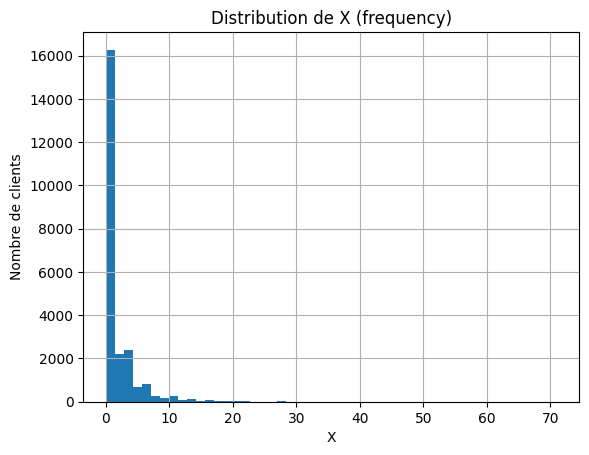

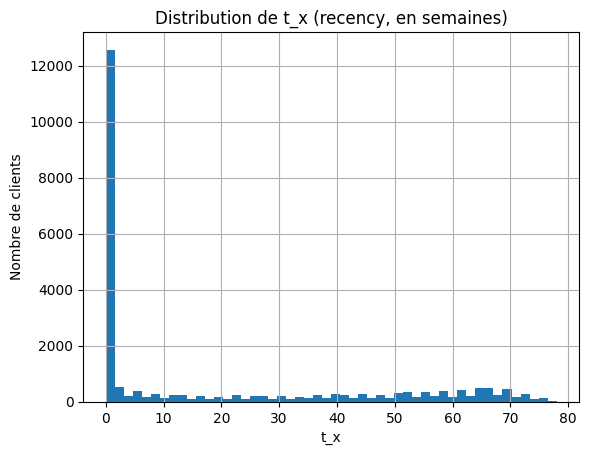

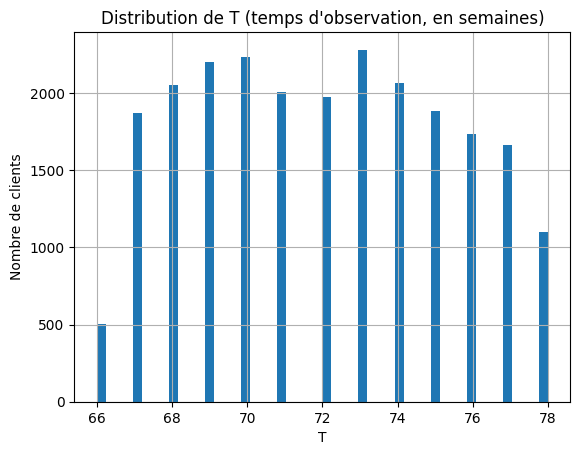

In [ ]:
# Distribution de frequency (= X répétés)
plt.figure()
rfm["frequency"].hist(bins=50)
plt.title("Distribution de X (frequency)")
plt.xlabel("X")
plt.ylabel("Nombre de clients")
plt.show()

# Distribution de recency (= t_x en semaines depuis premier achat)
plt.figure()
rfm["recency"].hist(bins=50)
plt.title("Distribution de t_x (recency, en semaines)")
plt.xlabel("t_x")
plt.ylabel("Nombre de clients")
plt.show()

# Distribution de T (âge/temps d'observation)
plt.figure()
rfm["T"].hist(bins=50)
plt.title("Distribution de T (temps d'observation, en semaines)")
plt.xlabel("T")
plt.ylabel("Nombre de clients")
plt.show()


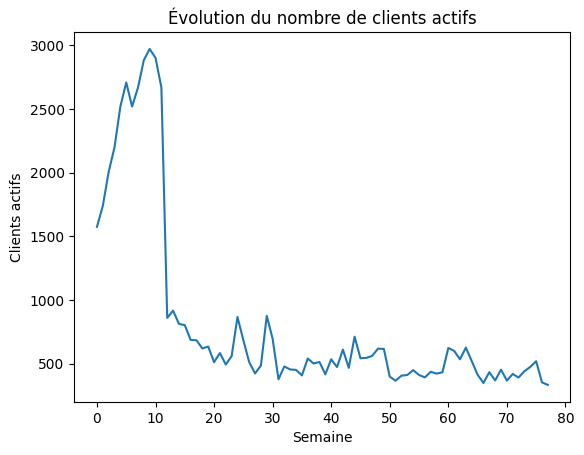

In [ ]:
# Nombre de clients actifs
active_customers = df.groupby("week")["customer_id"].nunique()

plt.figure()
active_customers.plot()
plt.xlabel("Semaine")
plt.ylabel("Clients actifs")
plt.title("Évolution du nombre de clients actifs")
plt.show()

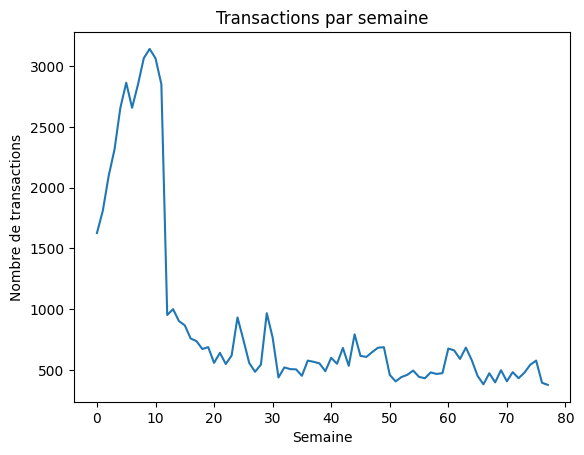

In [ ]:
# Evolution des transaction par semaine
transactions_per_week = df.groupby("week").size()

plt.figure()
transactions_per_week.plot()
plt.xlabel("Semaine")
plt.ylabel("Nombre de transactions")
plt.title("Transactions par semaine")
plt.show()

# même évolution que le nombre de clients actifs par semaine, probablement parce qu'un client actif ne fait qu'un achat par semaine.

##
La construction des statistiques $(x_i,t_{x_i},T_i)$ met en évidence
plusieurs caractéristiques importantes des données.

Tout d’abord, l’échantillon contient $N=23\,570$ clients, ce qui constitue une
taille suffisante pour étudier empiriquement les propriétés asymptotiques des
estimateurs considérés par la suite.

La distribution de la fréquence d’achat présente une forte hétérogénéité.
La moyenne empirique du nombre d’achats sur la période de calibration est
inférieure à 1, tandis que la variance est nettement plus élevée. Cette
sur-dispersion exclut un modèle de Poisson simple et est cohérente avec
l’utilisation d’une loi binomiale négative, comme motivé par l’analyse
théorique du mélange Gamma–Poisson.

Enfin, la récence montre qu’une proportion importante de clients n’effectue
aucun achat sur la période de calibration, ce qui justifie l’introduction d’un
mécanisme d’attrition et l’utilisation du cadre BTYD.


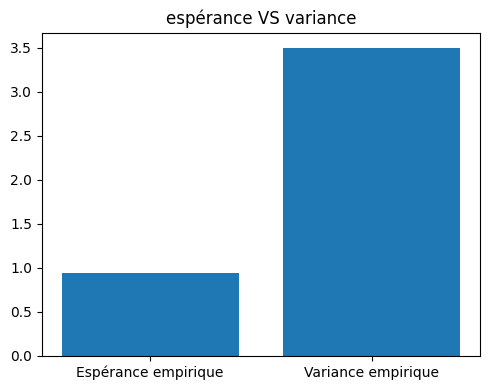

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(["Espérance empirique", "Variance empirique"], [mean_x, var_x])
plt.title("espérance VS variance")
plt.tight_layout()
plt.show()

##

On note $X$ la variable aléatoire représentant le nombre d’achats observés
pour un client sur la période de calibration.

Les moments empiriques sont donnés par :
$\bar X \approx 0.95,
\qquad
S^2 \approx 3.49.$

On observe que la variance empirique est très supérieure à la moyenne :
$S^2 \gg \bar X.$

Or, pour une loi de Poisson de paramètre $\lambda$, on a nécessairement
$\mathbb{E}[X] = \mathrm{Var}(X) = \lambda.$

***La sur-dispersion observée exclut donc un modèle de Poisson simple et motive
l’utilisation d’une loi binomiale négative, conformément au cadre théorique
développé précédemment.***


**Focus sur le temps écoulé avant une réactivation**

Nous souhaitons voir si les données comprennent des clients qui mettent beaucoup de temps à se réactiver (ie. effectuer un nouvel achat). On choisit un seuil de 10 semaines pour observer cela.

L'idée sera de voir plus bas si la modélisation Pareto/NBD à venir est capable de prendre en compte le fait qu'un client qui a churné peut ne pas être totalement "mort" mais revenir dans longtemps.

/tmp/ipython-input-3616932059.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diffs = df.groupby("customer_id").apply(inactivite_client)


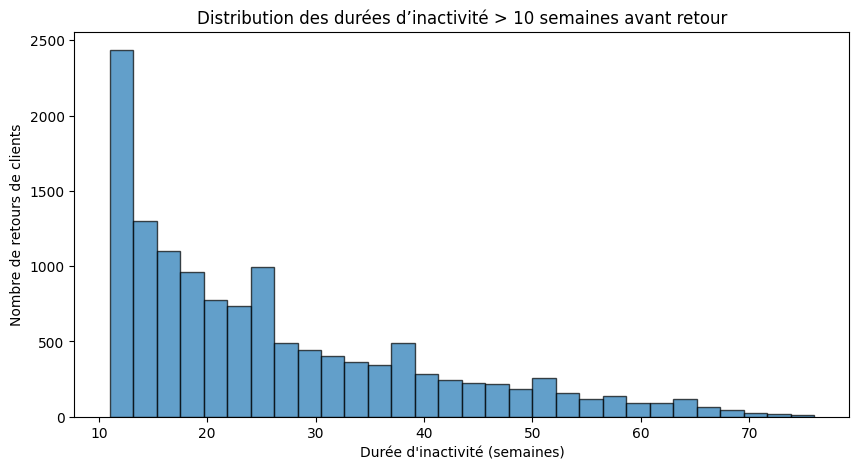

Nombre de retours après >10 semaines : 13104
Durée moyenne de ces longues inactivités : 25.9 semaines


In [ ]:
df = df.sort_values(["customer_id", "date"])

# Inactivité de chaque client
def inactivite_client(group):
    group = group.sort_values("date")
    group["diff_weeks"] = group["date"].diff().dt.days // 7
    # On garde uniquement les durées >0
    return group["diff_weeks"].dropna()

diffs = df.groupby("customer_id").apply(inactivite_client)
diffs = diffs.reset_index(drop=True)

# seuil d'inactivité fixé à 10 semaines
seuil = 10
longues_inactivites = diffs[diffs > seuil]

plt.figure(figsize=(10, 5))
plt.hist(longues_inactivites, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Durée d'inactivité (semaines)")
plt.ylabel("Nombre de retours de clients")
plt.title(f"Distribution des durées d’inactivité > {seuil} semaines avant retour")
plt.show()

print(f"Nombre de retours après >{seuil} semaines : {len(longues_inactivites)}")
print(f"Durée moyenne de ces longues périodes d'inactivités : {longues_inactivites.mean():.1f} semaines")

#### **Question 9 - Modèle Pareto / NBD**

In [ ]:
# On refait la RFM mais que pour le dataset des 39 premières semaines, ce qui nous permettra de faire la prédiction ensuite.

rfm_reduced = summary_data_from_transaction_data(
    cdnow_data,
    customer_id_col="customer_id",
    datetime_col="date",
    monetary_value_col="value",
    freq="W",
    observation_period_end = cdnow_data["date"].max()
)

In [ ]:
from lifetimes import ParetoNBDFitter

# On garde uniquement les colonnes nécessaires
# (frequency, recency, T)
data = rfm_reduced[["frequency", "recency", "T"]].copy()

# Fit Pareto/NBD (Maximum de vraisemblance)
pnbd = ParetoNBDFitter(penalizer_coef=0.0)
pnbd.fit(data["frequency"], data["recency"], data["T"])

params = pnbd.params_.to_frame(name="estimate_MV")
params.index.name = "parameter"
display(params)

,estimate_MV
parameter,
r,0.616786
alpha,14.472094
s,0.755102
beta,20.140932


##### **Interpretation des résulats**

### Interprétation des résultats

Les paramètres du modèle Pareto/NBD ont été estimés par maximum de vraisemblance à partir des données des 39 premières semaines. On obtient :
$$
\hat r = 0.62,\quad \hat\alpha = 14.47,\quad \hat s = 0.76,\quad \hat\beta = 20.14.
$$

La valeur de $(r)$, inférieure à 1, indique une forte hétérogénéité des fréquences d'achat entre les clients. La majorité des clients effectuent peu d'achats, tandis qu'une minorité concentre un nombre important de transactions, ce qui est cohérent avec la distribution observée de la variable `frequency`.

Le paramètre $(\alpha)$ est associé au niveau moyen de la fréquence d'achat. La valeur estimée suggère une fréquence d'achat relativement faible, ce qui correspond au caractère non contractuel et occasionnel des achats dans la base CDNOW.

Les paramètres $(s)$ et $(\beta)$ décrivent la distribution de la durée de vie des clients. La valeur $(s < 1)$ traduit une hétérogénéité marquée des comportements d'attrition, avec des clients quittant rapidement l'enseigne et d'autres restant actifs plus longtemps. Le paramètre $(\beta)$ fixe l'échelle de cette durée de vie.

Ces résultats sont globalement cohérents avec les statistiques descriptives et confirment la pertinence du modèle Pareto/NBD pour décrire le comportement d'achat observé.

#### **Question 10 - Lois binomiales négatives et de Pareto sous-jacentes au modèle**

##### **10.1 - Lois binomiales négatives sous-jacente au modèle**

#####**Méthode des moments pour la loi binomiale négative**

On suppose que $X$ suit une loi binomiale négative $\mathrm{NB}(r,p)$,
paramétrée par :
$\mathbb{P}(X=k)
= \frac{\Gamma(r+k)}{\Gamma(r)\,k!}\,p^r(1-p)^k,
\qquad k\in\mathbb{N}.$

Sous cette paramétrisation, l’espérance et la variance sont données par :
$\mathbb{E}[X] = \frac{r(1-p)}{p},
\qquad
\mathrm{Var}(X) = \frac{r(1-p)}{p^2}.$

La méthode des moments consiste à identifier ces quantités aux moments
empiriques observés, ce qui conduit aux estimateurs :
$\widehat r = \frac{\bar X^2}{S^2 - \bar X},
\qquad
\widehat p = \frac{\bar X}{S^2}.$


##

In [ ]:

# Vérification de la condition de sur-dispersion
if var_x <= mean_x:
    raise ValueError("Variance <= moyenne : la MoM NB n'est pas applicable.")

# Estimateurs MoM
r_hat_mom = mean_x**2 / (var_x - mean_x)
p_hat_mom = mean_x / var_x

r_hat_mom, p_hat_mom

print(f"r_hat_MoM = {r_hat_mom:.6f}")
print(f"p_hat_MoM = {p_hat_mom:.6f}")


r_hat_MoM = 0.350652
p_hat_MoM = 0.270625


##

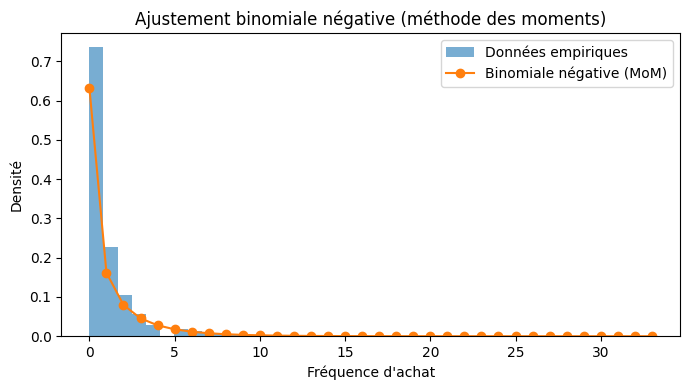

In [ ]:
from scipy.stats import nbinom
import numpy as np

k = np.arange(0, x.max()+1)

pmf_nb = nbinom.pmf(k, r_hat_mom, p_hat_mom)

plt.figure(figsize=(7,4))
plt.hist(x, bins=40, density=True, alpha=0.6, label="Données empiriques")
plt.plot(k, pmf_nb, 'o-', label="Binomiale négative (MoM)")
plt.xlabel("Fréquence d'achat")
plt.ylabel("Densité")
plt.legend()
plt.title("Ajustement binomiale négative (méthode des moments)")
plt.tight_layout()
plt.show()

La loi binomiale négative ajustée par la méthode des moments reproduit de manière
satisfaisante la forme générale de la distribution empirique, en particulier la
masse en zéro et la décroissance progressive de la queue.

##

L’application de la méthode des moments aux données de calibration conduit
aux estimations suivantes :
$\widehat r_{\text{MoM}} \approx {:0.35},
\qquad
\widehat p_{\text{MoM}} \approx {:0.27}.$

Ces valeurs sont cohérentes avec la forte hétérogénéité observée dans les
données : un paramètre $r$ relativement faible traduit une dispersion
importante des taux d’achat individuels.


#####**Interprétation via le mélange Gamma–Poisson**

Les résultats précédents s’interprètent naturellement dans le cadre du mélange Gamma–Poisson :
conditionnellement au taux d’achat individuel $(\Lambda)$, le nombre d’achats observés sur une période
de durée $(t)$ suit une loi de Poisson, et l’hétérogénéité inter-clients est modélisée par une loi Gamma :
$\Lambda \sim \Gamma(r,\alpha),
\qquad
X \mid \Lambda \sim \mathrm{Poisson}(\Lambda\,t).$

Dans ce cadre, la loi marginale de \(X\) est binomiale négative et peut s’écrire sous la forme
$\mathbb{P}(X=k)
= \frac{\Gamma(r+k)}{\Gamma(r)k!}
\left(\frac{\alpha}{\alpha+t}\right)^{r}
\left(\frac{t}{\alpha+t}\right)^{k},
\qquad k\in\mathbb{N}.$

On reconnaît alors la paramétrisation $(\mathrm{NB}(r,p))$ avec
$p=\frac{\alpha}{\alpha+t}
\qquad\Longleftrightarrow\qquad
\alpha=t\,\frac{p}{1-p}.$
Ainsi, l’estimation de \((r,p)\) par la méthode des moments permet d’identifier $(\alpha)$,
paramètre de la loi Gamma sous-jacente au mélange.


##

In [ ]:
## Calcul de 𝑡 et estimation de 𝛼

t_cal_mean = summary["T_cal"].mean()
t_cal_median = summary["T_cal"].median()

alpha_hat_mom_mean = t_cal_mean * p_hat_mom / (1 - p_hat_mom)
alpha_hat_mom_median = t_cal_median * p_hat_mom / (1 - p_hat_mom)

print(f"t_cal (mean)   = {t_cal_mean:.3f} semaines")
print(f"t_cal (median) = {t_cal_median:.3f} semaines")

print(f"alpha_hat_MoM (using mean t)   = {alpha_hat_mom_mean:.6f}")
print(f"alpha_hat_MoM (using median t) = {alpha_hat_mom_median:.6f}")


t_cal (mean)   = 33.010 semaines
t_cal (median) = 33.000 semaines
alpha_hat_MoM (using mean t)   = 12.248020
alpha_hat_MoM (using median t) = 12.244242


##

#####**Estimation de $\alpha$ (loi Gamma sous-jacente)**

Dans les données, la durée d’observation en calibration $(T_i)$ n’est pas strictement
constante : bien que la fenêtre maximale soit fixée à 39 semaines, les valeurs observées
varient typiquement entre 27 et 39 semaines. Afin de relier l’estimation du paramètre $p$
à $\alpha$, on introduit une durée représentative $t$, prise ici comme la durée moyenne
de la période de calibration (un choix alternatif, équivalent dans ce contexte, étant la
médiane).

Dans le cadre du mélange Gamma–Poisson, la relation entre les paramètres s’écrit :
$p = \frac{\alpha}{\alpha + t},$
ce qui conduit à l’estimateur par la méthode des moments :
$\widehat{\alpha}_{\mathrm{MoM}}
= t\,\frac{\widehat p_{\mathrm{MoM}}}{1-\widehat p_{\mathrm{MoM}}}.$

En utilisant la durée moyenne de calibration $t \approx 33.01$ semaines, on obtient :
$\widehat{\alpha}_{\mathrm{MoM}} \approx 12.25.$

À titre de comparaison, l’utilisation de la médiane $t = 33$ semaines conduit à une
estimation très proche, $\widehat{\alpha}_{\mathrm{MoM}} \approx 12.24$, ce qui confirme
la robustesse de l’estimation vis-à-vis du choix de la durée représentative.

Cette étape permet d’exprimer les résultats de la méthode des moments dans la
paramétrisation $(r,\alpha)$ du mélange Gamma–Poisson, qui constitue la composante
« fréquence » du cadre BTYD.


##### **10.2 - Loi de Pareto sous-jacente au modèle**

Pour chaque client i, le temps jusqu’au churn suit une loi exponentielle de paramètre $μ_i$

Si on pose $D_i$ la durée de vie du client après son dernier achat, on a : $D_i ∼ Exponential(μ_i)$

On sait donc que $\mathbb{E}[D_i] = μ_i$

$ μ_i ≈ \frac{1}{t_{x,i}}$

Donc, $t_{x,i}$ sera approximé par $\frac{1}{μ_i}$

In [ ]:
# taux d'achat
lambda_hat = rfm_reduced["frequency"] / rfm_reduced["T"]
lambda_hat = lambda_hat[lambda_hat > 0]

m2 = lambda_hat.mean()
v2 = lambda_hat.var()

# r par la méthode des moments
r_mm = m2**2 / v2
# alpha par la méthode des moments
alpha_mm = m2 / v2

print("Méthode des moments (achats)")
print("r =", r_mm)
print("alpha =", alpha_mm)

Méthode des moments (achats)
r = 1.1116450554971917
alpha = 15.271581385204982


Par la méthode des moments sur la loi de Pareto sous-jacente, on obtient $\hat{r}≈1.11$ et $\hat{\alpha}≈15.27$, proches de ceux obtenus par la méthode du maximum de vraisemblance (question 9, $r≈0.62$ et $\alpha≈14.47$)

On observe un écart sur l'estimation de r. Les taux d'achat individuels $\lambda_i$ ne sont pas observés et doivent être approximés par $\frac{f_i}{T_i}$. Si le client est peu actif son $\lambda_i$ estimé sera donc faible. La méthode des moments nous donne donc une estimation légèrement moins précise que la méthode du maximum de vraisemblance.

#### **Question 11 - Prévisions**

On reprend le modèle Pareto/NBD de la question 9

In [ ]:
# période future = 39 semaines (à prédire) pour comparer avec le second dataset qui servira de y_true
t_future = 39

rfm_reduced["predicted_purchases"] = pnbd.conditional_expected_number_of_purchases_up_to_time(
    t_future,
    rfm_reduced["frequency"],
    rfm_reduced["recency"],
    rfm_reduced["T"]
)

rfm_reduced[["frequency", "recency", "T", "predicted_purchases"]].head()

,frequency,recency,T,predicted_purchases
customer_id,,,,
1,0.0,0.0,39.0,0.122454
2,0.0,0.0,38.0,0.127024
3,2.0,13.0,39.0,0.610721
4,2.0,30.0,39.0,1.332379
5,7.0,37.0,39.0,4.407965


In [ ]:
holdout_counts = p2x.groupby("customer_id").size().rename("actual_purchases")

In [ ]:
pred_vs_actual = rfm_reduced[["predicted_purchases"]].join(holdout_counts, how="left")
pred_vs_actual["actual_purchases"] = pred_vs_actual["actual_purchases"].fillna(0)
pred_vs_actual.head()

,predicted_purchases,actual_purchases
customer_id,,
1,0.122454,0.0
2,0.127024,0.0
3,0.610721,3.0
4,1.332379,1.0
5,4.407965,3.0


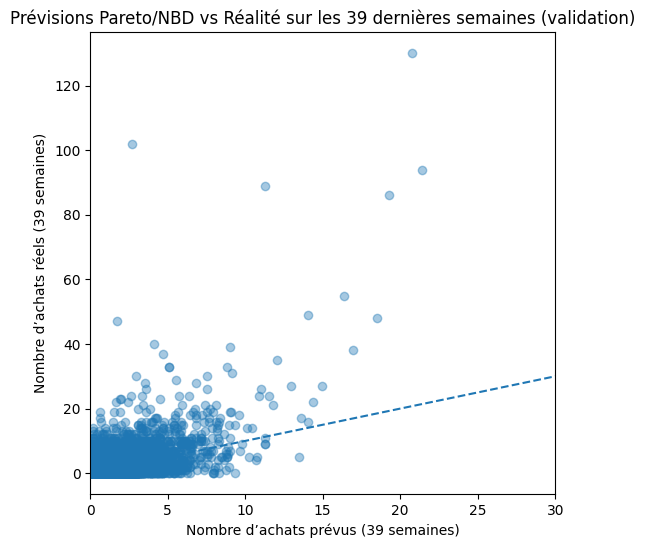

In [ ]:
# Visualisation sur les prédictions effectuées vs. la réalité
plt.figure(figsize=(6, 6))
plt.scatter(
    pred_vs_actual["predicted_purchases"],
    pred_vs_actual["actual_purchases"],
    alpha=0.4
)

max_val = max(pred_vs_actual.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")  # diagonale

plt.xlabel("Nombre d’achats prévus (39 semaines)")
plt.ylabel("Nombre d’achats réels (39 semaines)")
plt.xlim((0,30))
plt.title("Prévisions Pareto/NBD vs Réalité sur les 39 dernières semaines (validation)")
plt.show()

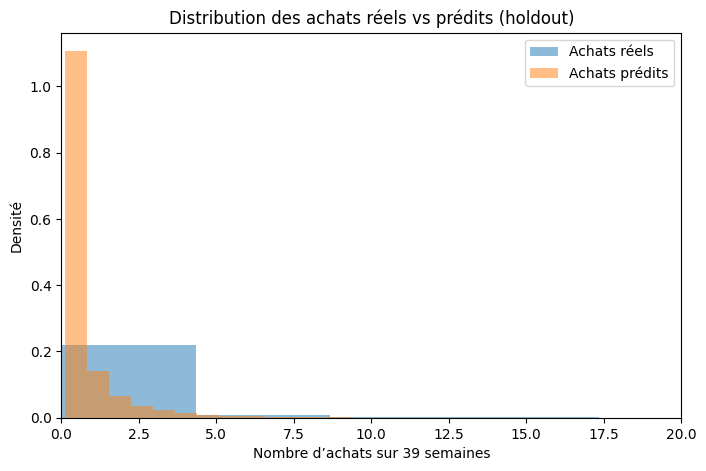

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(pred_vs_actual["actual_purchases"],
         bins=30, alpha=0.5, label="Achats réels", density=True)

plt.hist(pred_vs_actual["predicted_purchases"],
         bins=30, alpha=0.5, label="Achats prédits", density=True)

plt.xlabel("Nombre d’achats sur 39 semaines")
plt.ylabel("Densité")
plt.xlim((0,20))
plt.title("Distribution des achats réels vs prédits (holdout)")
plt.legend()
plt.show()

Le modèle Pareto/NBD montre (en prédiction) la forte proportion de clients qui n'ont pas fait d'achat sur la période de validation et la décroissance rapide de la fréquence d'achat.
La visualisation de la superposition des distributions ne montre pas une belle concordance entre prédictions et réalité. Mais cela peut être aussi dû au fait qu'on s'intéresse à une évolution temporelle des achats, et que le cumul des achats par clients par semaine n'est pas foncièrement ce qu'on souhaite mesurer. Regardons nos préctions dans le temps.

In [ ]:
# Réel sur calibration
reel_avant = cdnow_data.groupby("week").size()

# Réel sur holdout
reel_apres = p2x.groupby("week").size()

In [ ]:
# espérance cumulée pour chaque client
cum_preds = np.vstack([
    pnbd.conditional_expected_number_of_purchases_up_to_time(
        t,
        rfm_reduced["frequency"],
        rfm_reduced["recency"],
        rfm_reduced["T"]
    )
    for t in range(1, 40)
])

# passages en flux hebdomadaire
weekly_preds = np.diff(
    np.vstack([np.zeros(len(rfm_reduced)), cum_preds]),
    axis=0
)

# somme sur tous les clients
pred_holdout = weekly_preds.sum(axis=1)

# index en semaines réelles
pred_holdout = pd.Series(pred_holdout, index=range(39, 78))

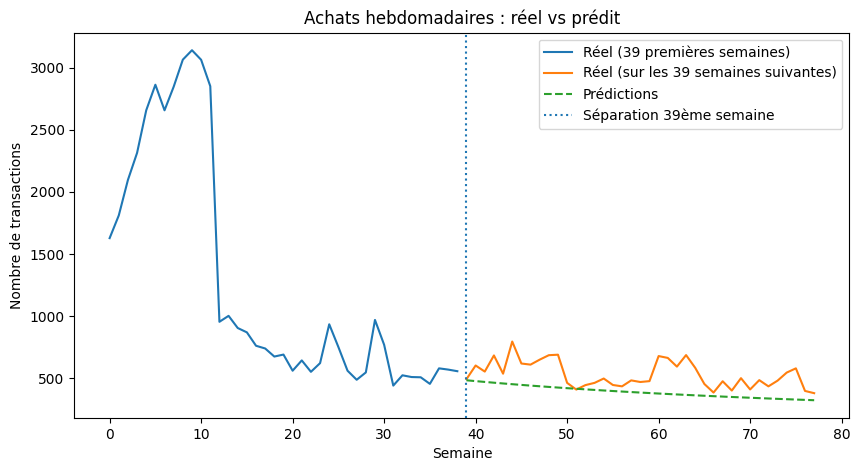

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(reel_avant.index, reel_avant.values, label="Réel (39 premières semaines)")
plt.plot(reel_apres.index, reel_apres.values, label="Réel (sur les 39 semaines suivantes)")
plt.plot(pred_holdout.index, pred_holdout.values, linestyle="--", label="Prédictions")

plt.axvline(39, linestyle=":", label="Séparation 39ème semaine")

plt.xlabel("Semaine")
plt.ylabel("Nombre de transactions")
plt.title("Achats hebdomadaires : réel vs prédit")
plt.legend()
plt.show()

**Conclusions de la prédiction**

On observe des prédictions (en vert) qui suivent bien la tendance du réel (en orange), sur les 39 dernières semaines.

Les prédictions sont faites le long d'une droite qui lisse toutes les variations de la réalité. C'est en fait cohérent, puisque la loi Pareto/NBD nous donne une espérance du nombre d'achat agregé sur tous les clients.

Le fait que la droite des prédictions soit décroissante est également cohérent : cela représente le churn progressive des clients qui ne se réactivent pas au cours du temps.

Notre modèle fit donc bien avec le réel, capture sa tendance sans pour autant être capable de reproduire ses fluctuations et variations bruitées, dûes par exemple au contexte économique individuel, à la temporalité (réception du salaire qui débloque le pouvoir d'achat), aux promotions qui boostent les ventes de CDs....

On peut enfin relever que le modèle Pareto/NBD sous-estime légèrement les ventes. Cette prudence est intéressante du point de vue métier où il est bon de rester prudent dans les projections. C'est également un élément à prendre en compte lors des prédictions et on peut notamment l'expliquer par le fait que le modèle n'est pas capable de prendre en compte la saisonnalité qui serait induites par des promotions ou offres commerciales ponctuelles, ou encore que le churn d'un client n'est pas toujours définitif dans la réalité et qu'un client n'ayant pas fait d'achat depuis longtemps peut se réactiver beaucoup plus tard (comme vu dans les visualisations).

## Annexe A — Démonstration : mélange Poisson–Gamma ⇒ loi binomiale négative

On considère un couple $(X,\Lambda)$ tel que conditionnellement à $\{\Lambda=\lambda\}$,
$$
X \mid (\Lambda=\lambda) \sim \mathrm{P}(\lambda)
,
\qquad\text{donc}\qquad
\mathbb{P}(X=k\mid\lambda)=e^{-\lambda}\frac{\lambda^k}{k!},\ k\in\mathbb{N}.
$$

On suppose que $\Lambda$ suit une loi Gamma $\gamma(n,\theta)$ (paramètres $n\in\mathbb{N}^*$ et $\theta>0$)
de densité (écriture du livret) :
$$
g(\lambda)=\frac{\lambda^{n-1}}{\Gamma(n)\theta^n}e^{-\lambda/\theta}\mathbf{1}_{(0,\infty)}(\lambda).
$$

### 1) Densité jointe $(X,\Lambda)$

Pour $\lambda>0$ et $k\in\mathbb{N}$,
$$
f_{X,\Lambda}(k,\lambda)
=\mathbb{P}(X=k\mid\lambda)\,g(\lambda)
=\left(e^{-\lambda}\frac{\lambda^k}{k!}\right)\left(\frac{\lambda^{n-1}}{\Gamma(n)\theta^n}e^{-\lambda/\theta}\right).
$$

En regroupant les termes,
$$
f_{X,\Lambda}(k,\lambda)
=\frac{1}{k!\,\Gamma(n)\theta^n}\lambda^{n+k-1}\exp\!\left(-\lambda\left(1+\frac{1}{\theta}\right)\right),
\qquad \lambda>0,\ k\ge 0.
$$

On retrouve bien l’expression attendue dans le livret :
$$
\boxed{
f(k,\lambda)=\frac{\lambda^{n+k-1}}{k!\,\Gamma(n)\,\theta^n}\,e^{-\lambda(1+1/\theta)}.
}
$$

### 2) Loi marginale de $X$

Par la formule des probabilités totales,
$$
\mathbb{P}(X=k)=\int_0^{\infty} f_{X,\Lambda}(k,\lambda)\,d\lambda.
$$

Donc, en utilisant l’expression précédente :
$$
\mathbb{P}(X=k)
=\frac{1}{k!\,\Gamma(n)\theta^n}
\int_0^\infty \lambda^{n+k-1}\exp\!\left(-\lambda\left(1+\frac{1}{\theta}\right)\right)\,d\lambda.
$$

On pose
$$
a = 1+\frac{1}{\theta} = \frac{\theta+1}{\theta} > 0.
$$
Alors
$$
\int_0^\infty \lambda^{n+k-1}e^{-a\lambda}\,d\lambda
= \frac{\Gamma(n+k)}{a^{\,n+k}}
\qquad\text{(intégrale Gamma).}
$$

Ainsi,
$$
\mathbb{P}(X=k)
=\frac{1}{k!\,\Gamma(n)\theta^n}\cdot \frac{\Gamma(n+k)}{a^{\,n+k}}.
$$

On remplace $a=(\theta+1)/\theta$ :
$$
\frac{1}{a^{\,n+k}}=\left(\frac{\theta}{\theta+1}\right)^{n+k}.
$$

Donc
$$
\mathbb{P}(X=k)
=\frac{\Gamma(n+k)}{\Gamma(n)\,k!}\cdot \frac{1}{\theta^n}\left(\frac{\theta}{\theta+1}\right)^{n+k}.
$$

Or
$$
\frac{1}{\theta^n}\left(\frac{\theta}{\theta+1}\right)^{n+k}
=\left(\frac{1}{\theta+1}\right)^n\left(\frac{\theta}{\theta+1}\right)^k.
$$

Finalement :
$$
\boxed{
\mathbb{P}(X=k)
=\frac{\Gamma(n+k)}{\Gamma(n)\,k!}
\left(\frac{1}{1+\theta}\right)^n
\left(\frac{\theta}{1+\theta}\right)^k,
\qquad k\in\mathbb{N}.
}
$$

### 3) Reconnaissance : loi binomiale négative

En posant
$$
r=n,
\qquad
p=\frac{1}{1+\theta},
\qquad
1-p=\frac{\theta}{1+\theta},
$$
on obtient
$$
\mathbb{P}(X=k)
=\frac{\Gamma(r+k)}{\Gamma(r)\,k!}\,p^r(1-p)^k,
\qquad k\in\mathbb{N}.
$$

Donc la loi marginale de $X$ est une **loi binomiale négative** :
$$
\boxed{
X\sim\mathrm{NB}(r,p)\quad\text{avec}\quad r=n,\ \ p=\frac{1}{1+\theta}.
}
$$
